In [1]:
import torch
import os
import math
from typing import Dict, Any

def window_permutation(H: int, W: int, Wh: int, Ww: int, hierarchical: bool = False) -> torch.Tensor:
    """
    Return a permutation idx such that x.view(H*W)[idx] is reordered
    window-by-window (raster scan over windows, raster scan inside each window).
    If hierarchical=True, first permute to window-first order with Wh x Ww windows,
    then within each window, permute to subwindow-first order with (Wh/4) x (Ww/4) subwindows.
    """
    if not (H % Wh == 0 and W % Ww == 0):
        raise ValueError(f"H({H}), W({W}) must be divisible by Wh({Wh}), Ww({Ww})")
    
    idx = torch.arange(H * W).reshape(H, W)
    
    if not hierarchical:
        # Non-hierarchical permutation
        patches = idx.unfold(0, Wh, Wh).unfold(1, Ww, Ww)  # (nWh, nWw, Wh, Ww)
        perm = patches.contiguous().view(-1)               # (H*W,)
        return perm
    
    # Hierarchical permutation
    if not (Wh % 4 == 0 and Ww % 4 == 0):
        raise ValueError(f"For hierarchical=True, Wh({Wh}) and Ww({Ww}) must be divisible by 4")
    
    # First level: permute to window-first order with Wh x Ww windows
    patches = idx.unfold(0, Wh, Wh).unfold(1, Ww, Ww)  # (nWh, nWw, Wh, Ww)
    
    # Second level: within each window, permute to subwindow-first order
    sub_Wh, sub_Ww = Wh // 4, Ww // 4
    # Shape: (nWh, nWw, 4, 4, sub_Wh, sub_Ww)
    hierarchical_patches = patches.unfold(2, sub_Wh, sub_Wh).unfold(3, sub_Ww, sub_Ww)
    
    # Reshape to get subwindow-first order. The memory layout from unfold is already
    # correct for a raster-scan-style flattening, so no permute is needed.
    perm = hierarchical_patches.contiguous().view(-1)   # (H*W,)
    return perm

def hilbert_window_permutation(H: int, W: int, Wh: int, Ww: int) -> torch.Tensor:
    """
    Return a permutation idx that orders tokens using Hilbert curves within windows.
    First, tokens are grouped into windows of size Wh x Ww.
    Within each window, tokens are ordered following a Hilbert curve pattern.
    Windows themselves are ordered in raster scan order.

    Args:
        H: Height of the 2D grid (tokens laid out row-major)
        W: Width of the 2D grid
        Wh: Window height
        Ww: Window width

    Returns:
        torch.LongTensor of shape (H*W,) with global indices in Hilbert-windowed order.
    """
    if Wh <= 0 or Ww <= 0:
        raise ValueError(f"Wh and Ww must be positive, got Wh={Wh}, Ww={Ww}")
    if H <= 0 or W <= 0:
        raise ValueError(f"H and W must be positive, got H={H}, W={W}")
    if (H % Wh) != 0 or (W % Ww) != 0:
        raise ValueError(f"H({H}), W({W}) must be divisible by Wh({Wh}), Ww({Ww})")

    # Next power of two that accommodates the window (works for rectangular windows too)
    n_side = 1 << math.ceil(math.log2(max(Wh, Ww)))

    # --- Hilbert helpers (iterative, reliable) ---
    def _rot(s: int, x: int, y: int, rx: int, ry: int):
        # Rotate/flip a quadrant appropriately
        if ry == 0:
            if rx == 1:
                x = s - 1 - x
                y = s - 1 - y
            # swap x and y
            x, y = y, x
        return x, y

    def _xy2d(n: int, x: int, y: int) -> int:
        # Map (x,y) in [0,n)×[0,n) to Hilbert distance d
        d = 0
        s = n // 2
        while s > 0:
            rx = 1 if (x & s) else 0
            ry = 1 if (y & s) else 0
            d += s * s * ((3 * rx) ^ ry)
            x, y = _rot(s, x, y, rx, ry)
            s //= 2
        return d

    # Precompute the Hilbert order (as (hilbert_d, h, w)) for a single Wh×Ww window,
    # embedding coordinates into n_side×n_side.
    per_window = []
    per_window.reserve if hasattr(per_window, "reserve") else None  # no-op in Python, keeps intent clear
    for h in range(Wh):
        for w in range(Ww):
            d = _xy2d(n_side, h, w)
            per_window.append((d, h, w))
    per_window.sort(key=lambda t: t[0])  # sort by Hilbert distance

    # Build global permutation by raster-scanning windows and applying within-window Hilbert order
    idx_grid = torch.arange(H * W, dtype=torch.long).reshape(H, W)
    num_windows_h = H // Wh
    num_windows_w = W // Ww

    perm = torch.empty(H * W, dtype=torch.long)
    out_ptr = 0
    for win_i in range(num_windows_h):
        h0 = win_i * Wh
        h1 = h0 + Wh
        for win_j in range(num_windows_w):
            w0 = win_j * Ww
            w1 = w0 + Ww
            window_indices = idx_grid[h0:h1, w0:w1]
            for _, h, w in per_window:
                perm[out_ptr] = window_indices[h, w]
                out_ptr += 1

    return perm

def _create_distance_mask_chunked(
    indices_h: torch.Tensor,
    indices_w: torch.Tensor,
    radius_h: int,
    radius_w: int,
    chunk_size: int = 4096,
) -> torch.Tensor:
    """
    Creates a boolean attention mask based on token distance in a memory-efficient way
    by processing the mask in horizontal chunks to avoid large intermediate tensors.
    """
    seq_len = indices_h.numel()
    mask = torch.empty(seq_len, seq_len, dtype=torch.bool, device=indices_h.device)
    
    indices_h_row = indices_h.unsqueeze(0)
    indices_w_row = indices_w.unsqueeze(0)

    for i in range(0, seq_len, chunk_size):
        end = min(i + chunk_size, seq_len)
        h_chunk_col = indices_h[i:end].unsqueeze(1)
        w_chunk_col = indices_w[i:end].unsqueeze(1)
        
        dist_mask_chunk = (torch.abs(h_chunk_col - indices_h_row) <= radius_h) & \
                          (torch.abs(w_chunk_col - indices_w_row) <= radius_w)
        mask[i:end, :] = dist_mask_chunk
        
    return mask

def _create_id_mask_chunked(
    query_ids: torch.Tensor,
    key_ids: torch.Tensor = None,
    chunk_size: int = 1024
) -> torch.Tensor:
    """
    Creates a boolean attention mask by matching IDs between query and key tokens.
    Processes the mask in chunks to conserve memory.
    """
    if key_ids is None:
        key_ids = query_ids

    seq_len_q = query_ids.numel()
    seq_len_k = key_ids.numel()
    mask = torch.empty(seq_len_q, seq_len_k, dtype=torch.bool, device=query_ids.device)

    key_ids_row = key_ids.unsqueeze(0)
    for i in range(0, seq_len_q, chunk_size):
        end = min(i + chunk_size, seq_len_q)
        query_chunk_col = query_ids[i:end].unsqueeze(1)
        mask[i:end, :] = (query_chunk_col == key_ids_row)
        
    return mask

def _build_mask(
    model_config: Dict[str, Any] = {},
    device: torch.device = torch.device("cuda:0"),
    dtype: torch.dtype = torch.bfloat16,
    block_idx: int = 0,
    image_size: tuple[int, int] = (2048, 2048),
    joint_denoise_H: int = 512,
    joint_denoise_W: int = 512,
) -> torch.Tensor:
    """Build unified KV representation and attention mask using memory-optimized, chunked operations."""
    
    text_seq_len = 512
    image_size = image_size
    patch_size = 16
    window_size = 256, 256
    
    H_p = image_size[0] // patch_size
    W_p = image_size[1] // patch_size
    window_patches_H = window_size[0] // patch_size
    window_patches_W = window_size[1] // patch_size
    joint_denoise_H = joint_denoise_H // patch_size
    joint_denoise_W = joint_denoise_W // patch_size
    
    shift_size_H = 0
    shift_size_W = 0
    if not model_config.get("use_sliding_window", True):
        if block_idx % 2 == 1: # Shift for odd layers
            shift_size_H = window_patches_H // 2
            shift_size_W = window_patches_W // 2
    
    h_windows = math.ceil(H_p / window_patches_H)
    w_windows = math.ceil(W_p / window_patches_W)
    
    hi_res_len = H_p * W_p
    low_res_len = joint_denoise_H * joint_denoise_W 
    total_q_len = text_seq_len + hi_res_len + low_res_len
    
    attention_mask = torch.zeros(total_q_len, total_q_len, dtype=torch.bool, device=device)
    
    # =================== Text Attention Patterns ===================
    if model_config.get("text_attend_scale", "hr_and_T") == "all":
        attention_mask[:text_seq_len, :] = True
    else:
        attention_mask[:text_seq_len, :-low_res_len] = True
    
    attention_mask[:-low_res_len, :text_seq_len] = True
    
    # =================== Hi-Res Window Attention ===================
    h_indices = torch.arange(hi_res_len, device=device) // W_p
    w_indices = torch.arange(hi_res_len, device=device) % W_p
    
    hi_res_start = text_seq_len
    hi_res_end = text_seq_len + hi_res_len
    
    if model_config.get("use_sliding_window", True):
        # --- Sliding Window Attention (Memory Optimized) ---
        window_radius_H = window_patches_H // 2
        window_radius_W = window_patches_W // 2
        # print(h_indices)
        # print(h_indices.shape)
        # print(window_radius_H)
        sliding_window_mask = _create_distance_mask_chunked(
            h_indices, w_indices, window_radius_H, window_radius_W
        )
        
        if model_config.get("permute_window_first", True):
            perm = window_permutation(H_p, W_p, window_patches_H, window_patches_W).to(device)
            sliding_window_mask = sliding_window_mask.index_select(0, perm).index_select(1, perm)
        
        attention_mask[hi_res_start:hi_res_end, hi_res_start:hi_res_end] = sliding_window_mask
        
    else:
        # --- Shifted Window Attention (Memory Optimized) ---
        shifted_h = h_indices
        shifted_w = w_indices
        if shift_size_H > 0 or shift_size_W > 0:
            shifted_h = (h_indices + shift_size_H) % H_p
            shifted_w = (w_indices + shift_size_W) % W_p
        
        window_h_ids = shifted_h // window_patches_H
        window_w_ids = shifted_w // window_patches_W
        window_ids = window_h_ids * w_windows + window_w_ids
        
        same_window_mask = _create_id_mask_chunked(window_ids)
        
        if model_config.get("use_overlap_window", False):
            window_h_ids_half = window_h_ids // 2
            window_w_ids_half = window_w_ids // 2
            window_ids_half = window_h_ids_half * w_windows + window_w_ids_half
            same_window_mask_half = _create_id_mask_chunked(window_ids_half)
            torch.logical_or(same_window_mask, same_window_mask_half, out=same_window_mask)

        attention_mask[hi_res_start:hi_res_end, hi_res_start:hi_res_end] = same_window_mask
    
    # =================== Hi-Res to Low-Res Attention ===================
    if model_config.get("hi_res_attend_scale", "all") == "all":
        scale_H = max(H_p // joint_denoise_H, 1)
        scale_W = max(W_p // joint_denoise_W, 1)
        win_H_lr = max(window_patches_H // scale_H, 1)
        win_W_lr = max(window_patches_W // scale_W, 1)

        h_lr_idx = torch.arange(low_res_len, device=device) // joint_denoise_W
        w_lr_idx = torch.arange(low_res_len, device=device) %  joint_denoise_W
        lr_win_h = h_lr_idx // win_H_lr
        lr_win_w = w_lr_idx // win_W_lr
        lr_w_windows = math.ceil(joint_denoise_W / win_W_lr)
        lr_window_ids = lr_win_h * lr_w_windows + lr_win_w

        target_lh = (h_indices // scale_H) // win_H_lr
        target_lw = (w_indices // scale_W) // win_W_lr
        target_lr_window_ids = target_lh * lr_w_windows + target_lw
        
        # This mask is [H, L], which is not N^2 and typically fits in memory.
        # If it ever becomes a bottleneck, it can also be chunked.
        # hr_to_lr = (target_lr_window_ids.unsqueeze(1) == lr_window_ids.unsqueeze(0))
        hr_to_lr = torch.abs(target_lr_window_ids.unsqueeze(1) - lr_window_ids.unsqueeze(0)) <= 1
        attention_mask[hi_res_start:hi_res_end, -low_res_len:] = hr_to_lr

        if model_config.get("permute_window_first", True):
                perm_hr = window_permutation(H_p, W_p, window_patches_H, window_patches_W).to(device)
                perm_lr = window_permutation(joint_denoise_H, joint_denoise_W, 4, 4).to(device)
                attention_mask[hi_res_start:hi_res_end, -low_res_len:] = (
                    attention_mask[hi_res_start:hi_res_end, -low_res_len:]
                    .index_select(0, perm_hr).index_select(1, perm_lr)
                )
        # lr_block = 256
        # hr_block = 4096
        # num_lr_blocks = low_res_len // lr_block
        # for i in range(num_lr_blocks):
        #     # Calculate absolute start/end indices for the hi-res block
        #     hr_start_abs = hi_res_start + i * hr_block
        #     hr_end_abs = hi_res_start + (i + 1) * hr_block
            
        #     # Calculate absolute start/end indices for the low-res block
        #     lr_start_abs = (total_q_len - low_res_len) + i * lr_block
        #     lr_end_abs = (total_q_len - low_res_len) + (i + 1) * lr_block

        #     # Ensure we don't go out of bounds
        #     hr_start_abs = max(hr_start_abs, hi_res_start)
        #     hr_end_abs = min(hr_end_abs, hi_res_end)
        #     lr_start_abs = max(lr_start_abs-64, total_q_len-low_res_len)
        #     lr_end_abs = min(lr_end_abs+64, total_q_len)
        #     attention_mask[hr_start_abs:hr_end_abs, lr_start_abs:lr_end_abs] = True
    # =================== Low-Res Attention (Memory Optimized) ===================
    if low_res_len > 0:
        h_lr_indices = torch.arange(low_res_len, device=device) // joint_denoise_W
        w_lr_indices = torch.arange(low_res_len, device=device) % joint_denoise_W
        
        # NOTE: The division by 4 in the permutation seems specific. Assuming this is intended.
        # The radius for the attention should likely not be divided by 4.
        # Using a radius based on the main window_size parameter for consistency.
        lr_radius_h = 4 // 2
        lr_radius_w = 4 // 2
        # lr_radius_h = window_patches_H // 2
        # lr_radius_w = window_patches_W // 2

        same_window_mask_lr = _create_distance_mask_chunked(
            h_lr_indices, w_lr_indices, lr_radius_h, lr_radius_w
        )
        attention_mask[-low_res_len:, -low_res_len:] = same_window_mask_lr

        if model_config.get("permute_window_first", True):
            # perm_lr_self = window_permutation(joint_denoise_H, joint_denoise_W, window_patches_H//2, window_patches_W//2).to(device)
            # perm_lr_self = window_permutation(joint_denoise_H, joint_denoise_W, 4, 4,).to(device)
            perm_lr_self = window_permutation(joint_denoise_H, joint_denoise_W, 4, 4).to(device)
            attention_mask[-low_res_len:, -low_res_len:] = attention_mask[-low_res_len:, -low_res_len:].index_select(0, perm_lr_self).index_select(1, perm_lr_self)
    # lr_block = 256
    # num_lr_blocks = low_res_len // lr_block
    # for i in range(num_lr_blocks):
    #     # Calculate absolute start/end indices for the low-res block
    #     lr_start_abs = (total_q_len - low_res_len) + i * lr_block
    #     lr_end_abs = (total_q_len - low_res_len) + (i + 1) * lr_block
    #     attention_mask[lr_start_abs:lr_end_abs, lr_start_abs:lr_end_abs] = True
    # attention_mask[-low_res_len:, -low_res_len:] = True

    return attention_mask



In [2]:
img_size = (6144, 6144)
mask = _build_mask(image_size=(img_size[0], img_size[1]), joint_denoise_H=img_size[0]//4, joint_denoise_W=img_size[1]//4)  
# Save the mask to a file
import torch
import os

# Create directory if it doesn't exist
save_dir = "attn_masks"
os.makedirs(save_dir, exist_ok=True)

#Save the mask with a descriptive filename
mask_filename = f"{save_dir}/attention_mask_{img_size}x{img_size}-test-window.pt"
torch.save(mask, mask_filename)
print(f"Attention mask saved to: {mask_filename}")
print(f"Mask shape: {mask.shape}")
print(f"Mask dtype: {mask.dtype}")
# print(f"Sparsity: {((mask.numel() - mask.sum()) / mask.numel() * 100):.2f}%")


Attention mask saved to: attn_masks/attention_mask_(6144, 6144)x(6144, 6144)-test-window.pt
Mask shape: torch.Size([157184, 157184])
Mask dtype: torch.bool


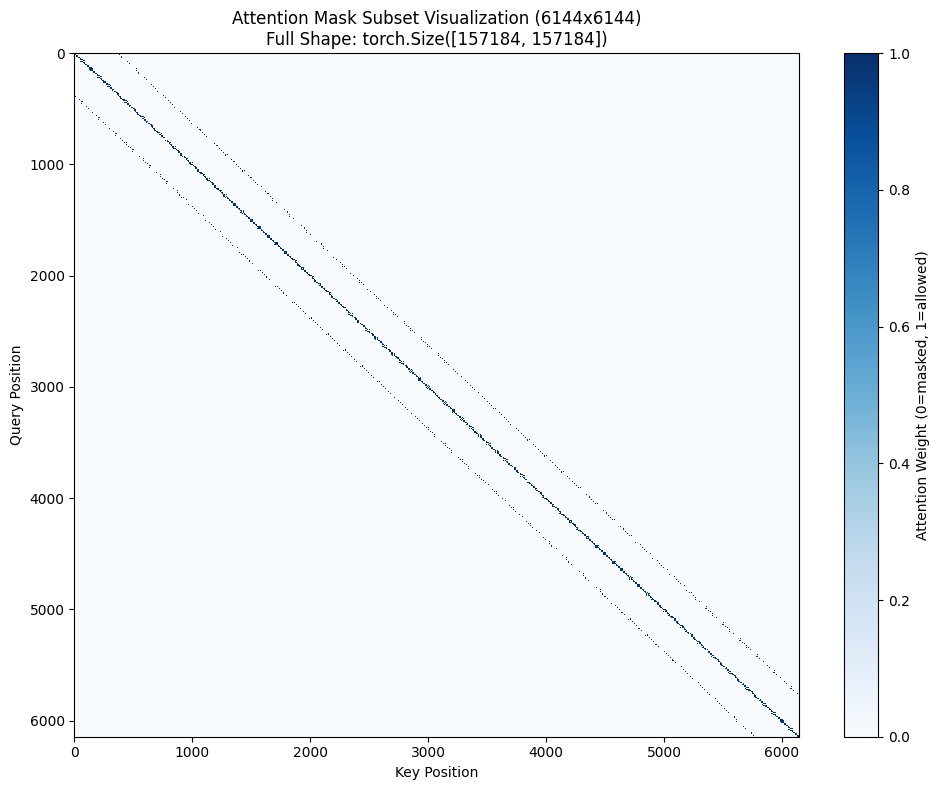

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize only a portion of the attention mask for better clarity
mask_np = mask.cpu().numpy()

# Choose a reasonable subset size based on the mask dimensions
subset_size = min(4096+2048, mask.shape[0])  # Show up to 512x512 or half the mask, whichever is smaller
start_idx = 0 # Start from the beginning


# Extract the subset
# mask_subset = mask_np[start_idx:start_idx+subset_size, start_idx:start_idx+subset_size]
mask_subset = mask_np[-subset_size:, -subset_size:]

plt.figure(figsize=(10, 8))
plt.imshow(mask_subset, cmap='Blues', aspect='auto', interpolation='nearest')
plt.colorbar(label='Attention Weight (0=masked, 1=allowed)')
plt.title(f'Attention Mask Subset Visualization ({subset_size}x{subset_size})\nFull Shape: {mask.shape}')
plt.xlabel('Key Position')
plt.ylabel('Query Position')

# Add grid lines for better visualization
if subset_size <= 100:
    plt.grid(True, alpha=0.3)

# Add some statistics as text
# total_elements = mask.numel()
# allowed_connections = mask.sum().item()
# sparsity = (total_elements - allowed_connections) / total_elements * 100

# subset_allowed = mask_subset.sum()
# subset_total = mask_subset.size
# subset_sparsity = (subset_total - subset_allowed) / subset_total * 100

# plt.figtext(0.02, 0.02, 
#     # f'Full mask - Total elements: {total_elements:,}\n'
#     # f'Full mask - Allowed connections: {allowed_connections:,}\n'
#     # f'Full mask - Sparsity: {sparsity:.1f}%\n'
#     # f'Subset - Sparsity: {subset_sparsity:.1f}%',
#     fontsize=10, 
#     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()


Original mask shape: torch.Size([157184, 157184])
Downsampled mask shape: torch.Size([1228, 2456])


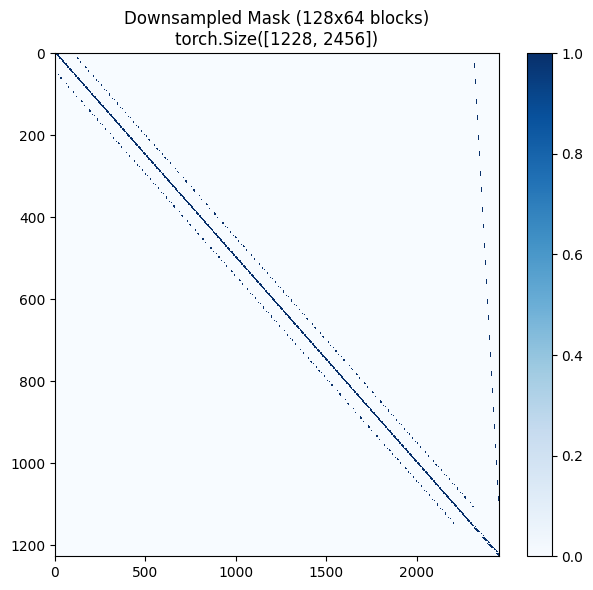

In [4]:
import torch

def downsample_mask_block(mask, block_size_q=128, block_size_k=64):
    """
    Downsample a 2D mask by taking blocks of size block_size_q x block_size_k.
    If any element in a block is 1, the corresponding output element is 1.
    
    Args:
        mask: torch.Tensor of shape (H, W) 
        block_size_q: int, size of each block in query dimension (default 128)
        block_size_k: int, size of each block in key dimension (default 64)
    
    Returns:
        torch.Tensor: downsampled mask of shape (H//block_size_q, W//block_size_k)
    """
    H, W = mask.shape
    
    # Calculate output dimensions
    H_out = H // block_size_q
    W_out = W // block_size_k
    
    # Trim mask to be divisible by block_size
    mask_trimmed = mask[:H_out * block_size_q, :W_out * block_size_k]
    
    # Reshape to group into blocks: (H_out, block_size_q, W_out, block_size_k)
    try:
        mask_reshaped = mask_trimmed.view(H_out, block_size_q, W_out, block_size_k)
    except:
        mask_reshaped = mask_trimmed.reshape(H_out, block_size_q, W_out, block_size_k)
    
    # Take max over the block dimensions (dim 1 and 3)
    # This gives us 1 if any element in the block is 1, 0 otherwise
    downsampled = mask_reshaped.max(dim=3)[0].max(dim=1)[0]
    torch.save(downsampled, f"/scratch/yuyao/HiHi_T2I/src_new/flux/attn_masks/{img_size}x{img_size}_downsampled_128_test-window.pt")
    
    return downsampled
import matplotlib.pyplot as plt

# mask = torch.load("/scratch3/ck1_23/efficient-attn/src_new/flux/attn_masks/attention_mask_70144x70144-test.pt")
# Test the function with our attention mask
print(f"Original mask shape: {mask.shape}")
downsampled_mask = downsample_mask_block(mask, block_size_q=128, block_size_k=64)
print(f"Downsampled mask shape: {downsampled_mask.shape}")

# Visualize the downsampled mask
plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 2)
plt.imshow(downsampled_mask.cpu().numpy(), cmap='Blues', aspect='auto', interpolation='nearest')
plt.title(f'Downsampled Mask (128x64 blocks)\n{downsampled_mask.shape}')
plt.colorbar()

plt.tight_layout()
plt.show()




In [ ]:
mask.shape

torch.Size([4864, 4864])

Original mask shape: torch.Size([4864, 4864])
Expanded mask shape: torch.Size([4864, 4864])


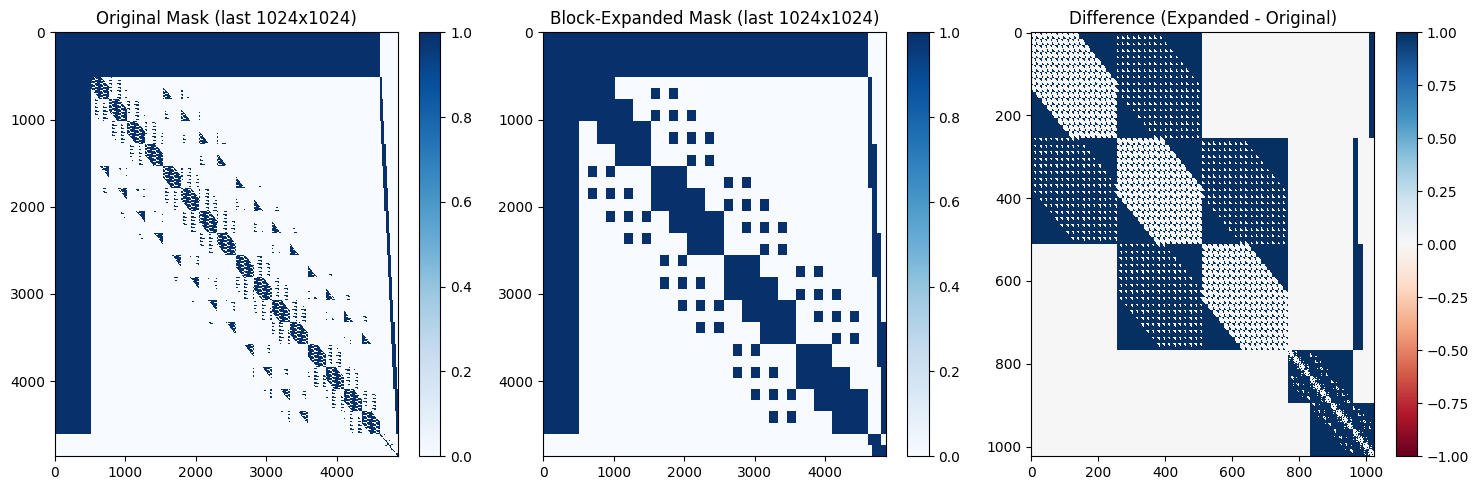

Original mask ones: 5,682,596 / 23,658,496 (24.02%)
Expanded mask ones: 8,470,528 / 23,658,496 (35.80%)
Increase in ones: 2,787,932 (11.78%)


In [9]:
# Create a block-expanded 
# mask where each 128x64 block is set to 1 if any entry in that block is 1
def expand_mask_blocks(mask, block_size_q=128, block_size_k=64):
    """
    Expand mask by setting all entries in a block to 1 if any entry in that block is 1.
    
    Args:
        mask: 2D tensor of shape (H, W)
        block_size_q: Block size in the first dimension (height)
        block_size_k: Block size in the second dimension (width)
    
    Returns:
        Expanded mask with same shape as input
    """
    H, W = mask.shape
    
    # Calculate number of complete blocks
    H_blocks = H // block_size_q
    W_blocks = W // block_size_k
    
    # Trim mask to be divisible by block sizes
    mask_trimmed = mask[:H_blocks * block_size_q, :W_blocks * block_size_k]
    
    # Reshape to group into blocks: (H_blocks, block_size_q, W_blocks, block_size_k)
    mask_reshaped = mask_trimmed.view(H_blocks, block_size_q, W_blocks, block_size_k)
    
    # Check if any element in each block is 1
    # Take max over the block dimensions (dim 1 and 3)
    block_has_ones = mask_reshaped.max(dim=3)[0].max(dim=1)[0]  # Shape: (H_blocks, W_blocks)
    
    # Expand each block decision back to full block size
    # First expand to (H_blocks, 1, W_blocks, 1)
    expanded_decisions = block_has_ones.unsqueeze(1).unsqueeze(3)
    
    # Then repeat to fill each block: (H_blocks, block_size_q, W_blocks, block_size_k)
    expanded_blocks = expanded_decisions.repeat(1, block_size_q, 1, block_size_k)
    
    # Reshape back to original trimmed dimensions
    expanded_mask = expanded_blocks.view(H_blocks * block_size_q, W_blocks * block_size_k)
    
    # If original mask was larger, pad back to original size
    if H > H_blocks * block_size_q or W > W_blocks * block_size_k:
        padded_mask = torch.zeros_like(mask)
        padded_mask[:H_blocks * block_size_q, :W_blocks * block_size_k] = expanded_mask
        # Handle remaining regions by copying original values
        if H > H_blocks * block_size_q:
            padded_mask[H_blocks * block_size_q:, :] = mask[H_blocks * block_size_q:, :]
        if W > W_blocks * block_size_k:
            padded_mask[:, W_blocks * block_size_k:] = mask[:, W_blocks * block_size_k:]
        return padded_mask
    torch.save(expanded_mask, f"/scratch/yuyao/HiHi_T2I/src_new/flux/attn_masks/mask_expanded_128x64_test-new.pt")
    
    return expanded_mask

# Test the function
expanded_mask = expand_mask_blocks(mask, block_size_q=128, block_size_k=64)
print(f"Original mask shape: {mask.shape}")
print(f"Expanded mask shape: {expanded_mask.shape}")

# Visualize comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask[-1024*10:, -1024*10:].cpu().numpy(), cmap='Blues', aspect='auto', interpolation='nearest')
plt.title('Original Mask (last 1024x1024)')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(expanded_mask[-1024*10:, -1024*10:].cpu().numpy(), cmap='Blues', aspect='auto', interpolation='nearest')
plt.title('Block-Expanded Mask (last 1024x1024)')
plt.colorbar()

plt.subplot(1, 3, 3)
diff = (expanded_mask.to(torch.float32) - mask.to(torch.float32))[-1024:, -1024:]
plt.imshow(diff.cpu().numpy(), cmap='RdBu', aspect='auto', interpolation='nearest', vmin=-1, vmax=1)
plt.title('Difference (Expanded - Original)')
plt.colorbar()

plt.tight_layout()
plt.show()

# Print statistics
original_ones = mask.sum().item()
expanded_ones = expanded_mask.sum().item()
total_elements = mask.numel()

print(f"Original mask ones: {original_ones:,} / {total_elements:,} ({100*original_ones/total_elements:.2f}%)")
print(f"Expanded mask ones: {expanded_ones:,} / {total_elements:,} ({100*expanded_ones/total_elements:.2f}%)")
print(f"Increase in ones: {expanded_ones - original_ones:,} ({100*(expanded_ones - original_ones)/total_elements:.2f}%)")
